# Dem4Cli v2 development

1. New population data gridded
2. new masks for countries
3. new cohort size data

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 80)
%matplotlib inline 

sys.path.append('..')

from population_demographics import * 

## 1. load new cohort size data

In [2]:
flags

{'version': 2, 'pop_resolution': 0.1, 'GMT_mapping': 'year_to_year'}

In [3]:
dir_cohortsizes

'/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/demographics4climate/data/cohort-sizes/WCDE_v3.2.beta'

In [4]:
filepath_cohortsizes=dir_cohortsizes+'/ssp_basic_drivers_release_3.2.beta_full.xlsx'

In [7]:
pd.read_excel(filepath_cohortsizes, sheet_name=1)

,Model,Scenario,Region,Variable,Unit,1950,1955,1960,1965,1970,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
0,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 100+,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 15-19,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 20-24,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 25-29,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Mean Years of Education|Female|Age 30-34,years,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406882,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP,billion USD_2015/yr,NaN,NaN,NaN,NaN,NaN,...,167.817493,202.230159,242.446718,289.227372,344.150188,408.863839,484.958158,574.577244,679.527459,801.530437
406883,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP,billion USD_2017/yr,NaN,NaN,NaN,NaN,NaN,...,142.607000,171.850000,206.025000,245.778000,292.450000,347.442000,412.105000,488.261000,577.445000,681.120000
406884,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP [per capita],USD_2010/yr,NaN,NaN,NaN,NaN,NaN,...,7173.363687,8652.728869,10446.998134,12612.926499,15222.120997,18366.588436,22153.943502,26753.568238,32317.872273,39014.010438
406885,OECD ENV-Growth 2025,SSP5,Zimbabwe,GDP|PPP [per capita],USD_2015/yr,NaN,NaN,NaN,NaN,NaN,...,8073.332338,9738.298355,11757.676253,14195.341521,17131.884994,20670.856635,24933.372446,30110.065103,36372.465515,43908.699720


In [9]:

df = pd.read_excel(filepath_cohortsizes, sheet_name=1)

# 1. Exclude rows where 'region' contains (R<number>)
df = df[~df['Region'].str.contains(r"\(R\d+\)", regex=True, na=False)]

# 2. Keep only:
#    - Exactly "Population"
#    - Or "Population|Male|Age <age>"
#    - Or "Population|Female|Age <age>"
population_pattern = (
    #r"^Population$"  # exactly 'Population'
    r"^Population\|(Male|Female)\|Age\s\d{1,2}(-\d{1,2})?$"  # age range
)

df = df[df['Variable'].str.contains(population_pattern, regex=True, na=False)]

In [10]:
df

,Model,Scenario,Region,Variable,Unit,1950,1955,1960,1965,1970,...,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100
38,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 0-4,million,0.630666,0.633850,0.713825,0.820112,0.949960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 10-14,million,0.405776,0.443287,0.511051,0.525418,0.608655,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 15-19,million,0.353874,0.386877,0.422271,0.493369,0.508750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 20-24,million,0.304909,0.332729,0.363826,0.402941,0.472583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,IIASA-WiC POP 2025,Historical Reference,Afghanistan,Population|Female|Age 25-29,million,0.260842,0.283533,0.309770,0.343994,0.382745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399088,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 75-79,million,NaN,NaN,NaN,NaN,NaN,...,0.143250,0.204322,0.211735,0.242217,0.319896,0.395627,0.438217,0.529094,0.565268,0.594757
399095,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 80-84,million,NaN,NaN,NaN,NaN,NaN,...,0.070287,0.106202,0.155388,0.165164,0.193778,0.263518,0.334017,0.378790,0.467772,0.510505
399102,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 85-89,million,NaN,NaN,NaN,NaN,NaN,...,0.026024,0.042097,0.065886,0.099905,0.110098,0.133990,0.190208,0.250217,0.294268,0.376550
399109,IIASA-WiC POP 2025,SSP5,Zimbabwe,Population|Male|Age 90-94,million,NaN,NaN,NaN,NaN,NaN,...,0.007523,0.011178,0.018921,0.031030,0.049368,0.057166,0.073223,0.110432,0.153345,0.190379


In [12]:
# Extract sex and age from Variable
df['sex'] = df['Variable'].str.extract(r"^Population\|(Male|Female)", expand=False)
df['age'] = df['Variable'].str.extract(r"Age\s([\d\+]+(?:-\d+)?)", expand=False)


In [55]:
# Melt year columns to long format
year_cols = [c for c in df.columns if re.match(r"^\d{4}$", str(c))]
df_long = df.melt(
    id_vars=['Region', 'sex', 'age','Scenario'],
    value_vars=year_cols,
    var_name='time',
    value_name='population'
)
df_long['time'] = df_long['time'].astype(int)
df_long['Scenario'] = df_long['Scenario'].replace({'Historical Reference': 'historical'})



In [56]:
df_long

,Region,sex,age,Scenario,time,population
0,Afghanistan,Female,0-4,historical,1950,0.630666
1,Afghanistan,Female,10-14,historical,1950,0.405776
2,Afghanistan,Female,15-19,historical,1950,0.353874
3,Afghanistan,Female,20-24,historical,1950,0.304909
4,Afghanistan,Female,25-29,historical,1950,0.260842
...,...,...,...,...,...,...
1546275,Zimbabwe,Male,75-79,SSP5,2100,0.594757
1546276,Zimbabwe,Male,80-84,SSP5,2100,0.510505
1546277,Zimbabwe,Male,85-89,SSP5,2100,0.376550
1546278,Zimbabwe,Male,90-94,SSP5,2100,0.190379


In [57]:
df_long.set_index(['Region', 'time', 'age', 'sex','Scenario'])

population
Region      time age   sex    Scenario              
Afghanistan 1950 0-4   Female historical    0.630666
                 10-14 Female historical    0.405776
                 15-19 Female historical    0.353874
                 20-24 Female historical    0.304909
                 25-29 Female historical    0.260842
...                                              ...
Zimbabwe    2100 75-79 Male   SSP5          0.594757
                 80-84 Male   SSP5          0.510505
                 85-89 Male   SSP5          0.376550
                 90-94 Male   SSP5          0.190379
                 95-99 Male   SSP5          0.069001

[1546280 rows x 1 columns]

In [65]:
da = df_long.set_index(['Region', 'time', 'age', 'sex', 'Scenario']).to_xarray()['population']
da

<xarray.DataArray 'population' (Region: 237, time: 31, age: 20, sex: 2,
                                Scenario: 6)>
array([[[[[         nan,          nan,          nan,          nan,
                    nan, 6.306660e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 6.189320e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.057760e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.422050e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 3.538740e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 3.978560e-01]],

         ...,

         [[         nan,          nan,          nan,          nan,
                    nan, 5.470000e-04],
          [         nan,          nan,          nan,          nan,
...
           3.394190e-01,          nan],
          [3.936120e-01, 7.289390e-01, 1.218630e+00, 1.114638e+00,
           3.430200e-01,          nan]],

         ...,

         [[6.621990e-01, 2.322970e-01, 1.273710e-01, 1.195540e-01,
           5.748720e-01,          nan],
          [4.689500e-01, 1.444020e-01, 6.366200e-02, 5.725400e-02,
           3.765500e-01,          nan]],

         [[4.044000e-01, 8.770100e-02, 4.394000e-02, 4.172300e-02,
           3.561450e-01,          nan],
          [2.321220e-01, 4.419300e-02, 1.674300e-02, 1.529800e-02,
           1.903790e-01,          nan]],

         [[1.947570e-01, 2.326400e-02, 1.104300e-02, 1.061500e-02,
           1.742830e-01,          nan],
          [8.197700e-02, 8.876000e-03, 3.021000e-03, 2.806000e-03,
           6.900100e-02,          nan]]]]])
Coordinates:
  * Region    (Region) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time      (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age       (age) object '0-4' '10-14' '15-19' ... '85-89' '90-94' '95-99'
  * sex       (sex) object 'Female' 'Male'
  * Scenario  (Scenario) object 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5' 'historical'

In [66]:
da = da.rename({'Region':'country', 'Scenario':'ssp'})
da

<xarray.DataArray 'population' (country: 237, time: 31, age: 20, sex: 2, ssp: 6)>
array([[[[[         nan,          nan,          nan,          nan,
                    nan, 6.306660e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 6.189320e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 4.057760e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 4.422050e-01]],

         [[         nan,          nan,          nan,          nan,
                    nan, 3.538740e-01],
          [         nan,          nan,          nan,          nan,
                    nan, 3.978560e-01]],

         ...,

         [[         nan,          nan,          nan,          nan,
                    nan, 5.470000e-04],
          [         nan,          nan,          nan,          nan,
...
           3.394190e-01,          nan],
          [3.936120e-01, 7.289390e-01, 1.218630e+00, 1.114638e+00,
           3.430200e-01,          nan]],

         ...,

         [[6.621990e-01, 2.322970e-01, 1.273710e-01, 1.195540e-01,
           5.748720e-01,          nan],
          [4.689500e-01, 1.444020e-01, 6.366200e-02, 5.725400e-02,
           3.765500e-01,          nan]],

         [[4.044000e-01, 8.770100e-02, 4.394000e-02, 4.172300e-02,
           3.561450e-01,          nan],
          [2.321220e-01, 4.419300e-02, 1.674300e-02, 1.529800e-02,
           1.903790e-01,          nan]],

         [[1.947570e-01, 2.326400e-02, 1.104300e-02, 1.061500e-02,
           1.742830e-01,          nan],
          [8.197700e-02, 8.876000e-03, 3.021000e-03, 2.806000e-03,
           6.900100e-02,          nan]]]]])
Coordinates:
  * country  (country) object 'Afghanistan' 'Albania' ... 'Zambia' 'Zimbabwe'
  * time     (time) int64 1950 1955 1960 1965 1970 ... 2080 2085 2090 2095 2100
  * age      (age) object '0-4' '10-14' '15-19' ... '85-89' '90-94' '95-99'
  * sex      (sex) object 'Female' 'Male'
  * ssp      (ssp) object 'SSP1' 'SSP2' 'SSP3' 'SSP4' 'SSP5' 'historical'

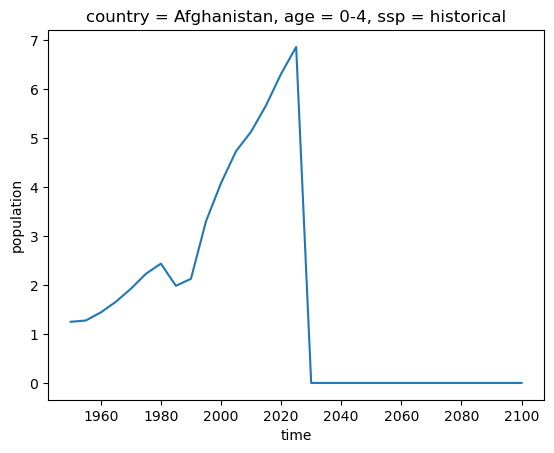

In [67]:
da.sel(ssp='historical', country='Afghanistan',age='0-4').sum(dim='sex').plot()